In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = "../data/raw"
LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]


In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
print(train.shape)
train.head()


(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
label_counts = train[LABEL_COLS].sum().sort_values(ascending=False)
label_pct = (label_counts / len(train) * 100).round(2)

summary = pd.DataFrame({"count": label_counts, "% of all comments": label_pct})
summary


,count,% of all comments
toxic,15294,9.58
obscene,8449,5.29
insult,7877,4.94
severe_toxic,1595,1.00
identity_hate,1405,0.88
threat,478,0.30


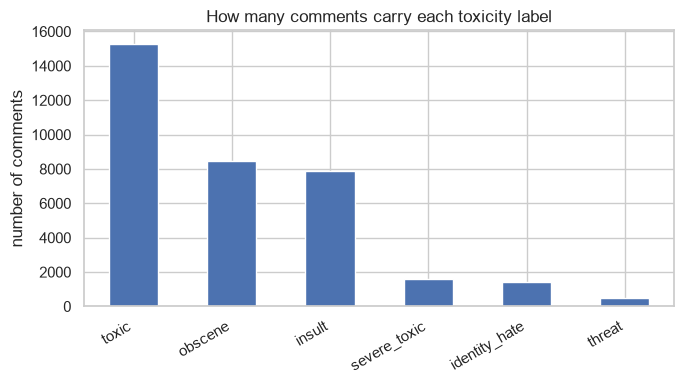

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
label_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("number of comments")
ax.set_title("How many comments carry each toxicity label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Clean comments (no label at all): 89.8%
At least one toxic label:         10.2%


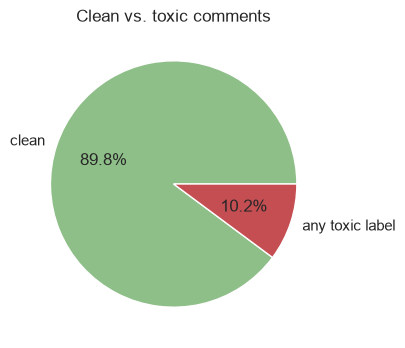

In [5]:
train["any_label"] = train[LABEL_COLS].max(axis=1)
clean_pct = (train["any_label"] == 0).mean() * 100
toxic_pct = (train["any_label"] == 1).mean() * 100

print(f"Clean comments (no label at all): {clean_pct:.1f}%")
print(f"At least one toxic label:         {toxic_pct:.1f}%")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie([clean_pct, toxic_pct], labels=["clean", "any toxic label"],
       autopct="%1.1f%%", colors=["#8FBF88", "#C44E52"])
ax.set_title("Clean vs. toxic comments")
plt.show()


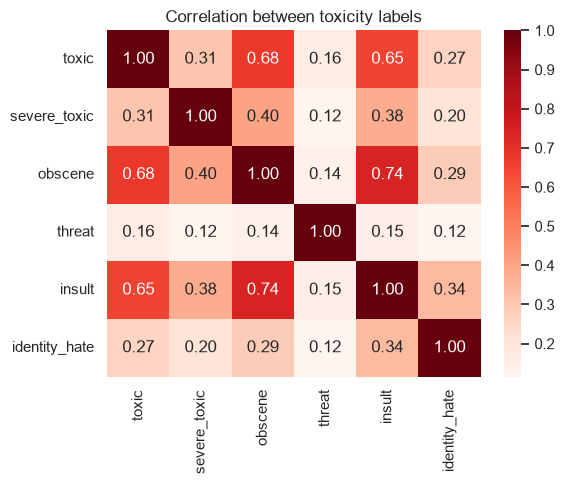

In [6]:
corr = train[LABEL_COLS].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Reds", ax=ax)
ax.set_title("Correlation between toxicity labels")
plt.tight_layout()
plt.show()


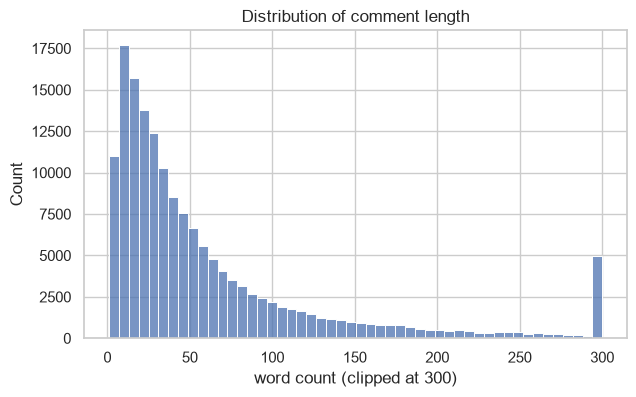

count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: word_count, dtype: float64


In [7]:
train["word_count"] = train["comment_text"].str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train["word_count"].clip(upper=300), bins=50, ax=ax, color="#4C72B0")
ax.set_xlabel("word count (clipped at 300)")
ax.set_title("Distribution of comment length")
plt.show()

print(train["word_count"].describe())


In [8]:
print("--- Example CLEAN comments ---")
for t in train.loc[train["any_label"] == 0, "comment_text"].sample(3, random_state=42):
    print("-", t[:200].replace("\n", " "))

print()
print("--- Example TOXIC comments ---")
for t in train.loc[train["toxic"] == 1, "comment_text"].sample(3, random_state=42):
    print("-", t[:200].replace("\n", " "))


--- Example CLEAN comments ---
- "  Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both w
- Are you trying to dispute that fact?
- SWOT analysis   This source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times, with no indication of how to find it or whether it's a primary source (I assume it is), so I'm goin

--- Example TOXIC comments ---
- Hi!   I wanna rape you!
- Terrorize  I will terrorise you for as long as you live - you are an arrogant, disgusting and rude excuse for a human being & you are going to die soon so I suggest you stop threatening people you bas
- Being blocked  So that's your idea of mediation, is it? R Lopez can run amok through Wikipedia with his lying crap, and I get blocked for stating my intention of stopping him unless Wikipedia's rather
